# Data & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk

In [2]:
import os
# Install Kaggle API client
!pip install kaggle
# Make a directory for Kaggle and move the kaggle.json file there
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
# Set permissions
!chmod 600 ~/.kaggle/kaggle.json
print('Kaggle API client installed and configured.')

Kaggle API client installed and configured.


Now you can download your dataset. You'll need the dataset's 'API command' from Kaggle. Go to the dataset page on Kaggle, click on the '...' (three dots) next to the 'Download' button, and copy the 'API command'. It usually looks like `kaggle datasets download -d <owner>/<dataset-name>`.

Replace `<owner>/<dataset-name>` in the cell below with your dataset's specific path.

In [3]:
# Replace with the actual Kaggle dataset path, e.g., 'titanic/titanic'
kaggle_dataset_path = "yashdogra/nlpdataset"
# Download the dataset
!kaggle datasets download -d {kaggle_dataset_path}
print(f'Dataset "{kaggle_dataset_path}" downloaded.')

Dataset URL: https://www.kaggle.com/datasets/yashdogra/nlpdataset
License(s): apache-2.0
100% 481k/481k [00:00<00:00, 24.4MB/s]

Dataset "yashdogra/nlpdataset" downloaded.


Kaggle datasets are often downloaded as ZIP files. You'll need to unzip them to access the data. The command below will unzip all `.zip` files in the current directory.

In [5]:
import zipfile
import glob
# Get a list of all zip files in the current directory
zip_files = glob.glob('*.zip')
for zip_file in zip_files:
    with zipfile.ZipFile(zip_file, 'r') as zf:
        zf.extractall('.')
    print(f'Extracted {zip_file}')
print('All zip files extracted. Now you can load your dataset.')

Extracted nlpdataset.zip
All zip files extracted. Now you can load your dataset.


# Exploratory
- The dataset contains short text samples describing seniment around a topic. This dataset is a good example to test pre-processing techniques and sentiment analysis for real world insights.
- categorized into three sentiment classes: Positive, Neutral, and Negative. Each entry includes a sentence and its associated sentiment label.

- [Data KagglePage](https://www.kaggle.com/datasets/yashdogra/nlpdataset)
- [Text Operations](https://www.kaggle.com/code/stieranka/text-analysis-operations-using-nltk/notebook)

In [8]:

#Two methods for reading file types. Encoding is latin to avoid special character errors with utf8 encoding.
text_data = pd.read_csv("/content/nlpdataset/nlpdataset/labelled sentences.csv", encoding='latin1')
display(text_data)

excel_data = pd.read_excel("/content/nlpdataset/nlpdataset/labelled sentences(1).xlsx")


,Sentences,Label
0,UN Humanitarian Chief Mark Lowcock today relea...,1
1,The announcement came as the World Health Orga...,0
2,The WHO has said there is still a chance of co...,1
3,"There are now cases linked to Iran in Bahrain,...",1
4,Extensive testing in clinical trials has confi...,1
...,...,...
684,"In November 2021, one stringent regulatory aut...",1
685,Trials in children as young as age 3 years wer...,1
686,"Covaxin, an adjuvanted inactivated vaccine dev...",1
687,The Indian regulatory authorities have given a...,1


## Tokenize (word and sent)

In [42]:
# analyze different portions of the text, and identify common metrics.
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('punkt_tab')
#iterate and tokenize the dataset
word_tokens = []
sent_tokens = []
for row in text_data.itertuples(index=False):
  word_tokens.append(word_tokenize(row.Sentences.lower()))
  sent_tokens.append(sent_tokenize(row.Sentences.lower()))

text_data_t = text_data.copy()
text_data_t['word_tokens'] = word_tokens
text_data_t['sent_tokens'] = sent_tokens

display(text_data_t)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Sentences,Label,word_tokens,sent_tokens
0,UN Humanitarian Chief Mark Lowcock today relea...,1,"[un, humanitarian, chief, mark, lowcock, today...",[un humanitarian chief mark lowcock today rele...
1,The announcement came as the World Health Orga...,0,"[the, announcement, came, as, the, world, heal...",[the announcement came as the world health org...
2,The WHO has said there is still a chance of co...,1,"[the, who, has, said, there, is, still, a, cha...",[the who has said there is still a chance of c...
3,"There are now cases linked to Iran in Bahrain,...",1,"[there, are, now, cases, linked, to, iran, in,...",[there are now cases linked to iran in bahrain...
4,Extensive testing in clinical trials has confi...,1,"[extensive, testing, in, clinical, trials, has...",[extensive testing in clinical trials has conf...
...,...,...,...,...
684,"In November 2021, one stringent regulatory aut...",1,"[in, november, 2021, ,, one, stringent, regula...","[in november 2021, one stringent regulatory au..."
685,Trials in children as young as age 3 years wer...,1,"[trials, in, children, as, young, as, age, 3, ...",[trials in children as young as age 3 years we...
686,"Covaxin, an adjuvanted inactivated vaccine dev...",1,"[covaxin, ,, an, adjuvanted, inactivated, vacc...","[covaxin, an adjuvanted inactivated vaccine de..."
687,The Indian regulatory authorities have given a...,1,"[the, indian, regulatory, authorities, have, g...",[the indian regulatory authorities have given ...


In [43]:
print(text_data_t.dtypes) #obj data types are for strings, lists, and mixed data types.

Sentences      object
Label           int64
word_tokens    object
sent_tokens    object
dtype: object


## Common Metrics
- Reviewing tokenization, word counts
- stop word removal, and punctuation cleaning.
> Key Note: Use Lemmatization for tasks requiring high semantic accuracy like NER, POS tagging, and parsing.
Use Stemming when speed is more important than precision, such as in search engines or basic text normalization.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


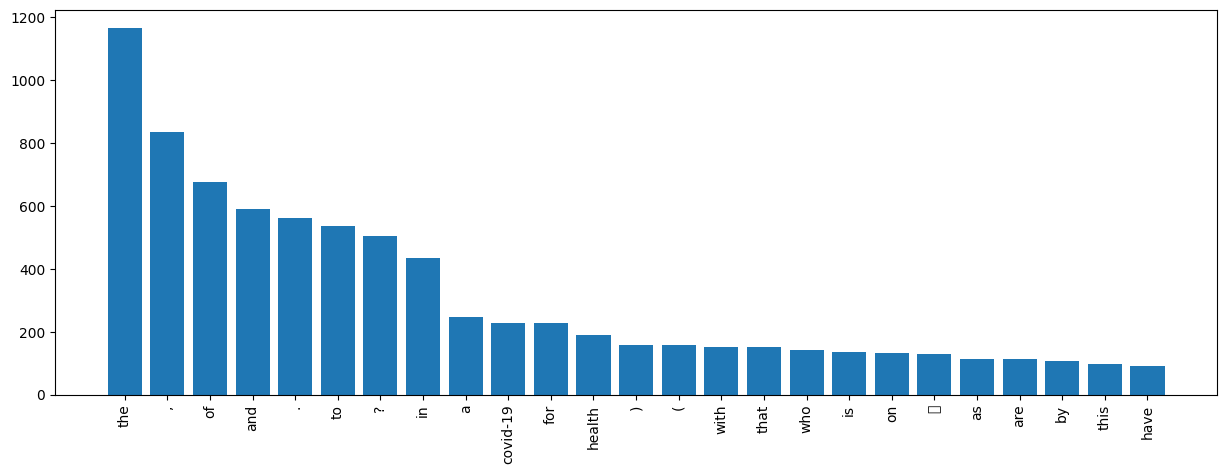

In [44]:
from collections import Counter

#determine most common words, including stop words.
ctr = Counter()
for item in text_data_t.word_tokens:
  ctr.update(item)

## Visualize top 25 most common tokens. This will be cleaner after removing stop words and punctuation.
words, counts = zip(*ctr.most_common(25))
plt.figure(figsize=(15,5))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


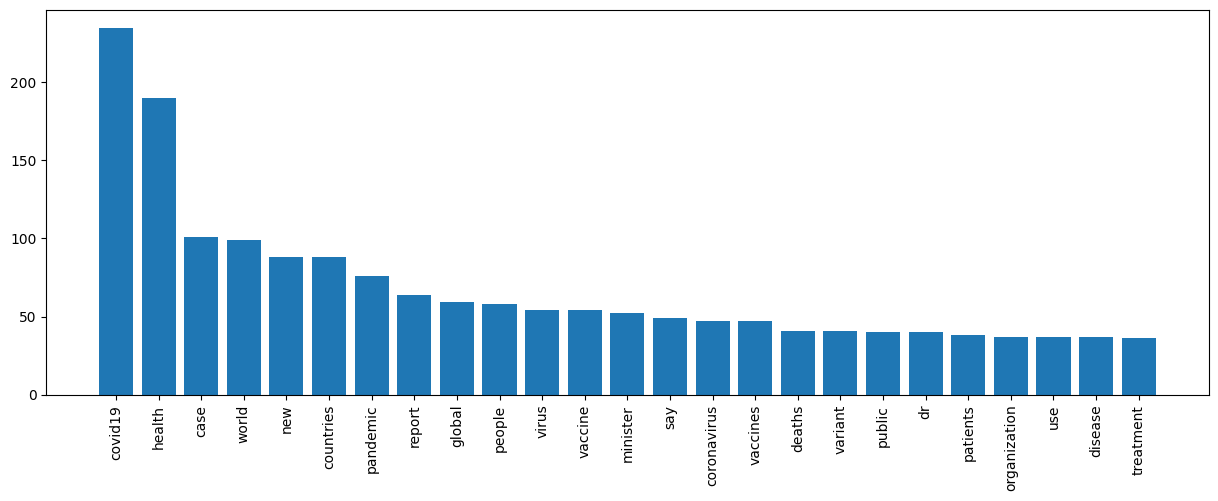

In [58]:
#Normalize and perform textual cleaning
from nltk.corpus import stopwords
import re
from nltk.stem import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer

#removing stop words
nltk.download('stopwords')
nltk.download('wordnet')

ps = PorterStemmer()
lem = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

cleaned_ctr = Counter()
for tokens in text_data_t.word_tokens:
  tokens = [re.sub(r'[^\w\s]', '', token) for token in tokens if re.sub(r'[^\w\s]', '', token)]
  cleaned_tokens = [token for token in tokens if token not in stop_words]
  # cleaned_tokens = [ps.stem(token) for token in cleaned_tokens]
  cleaned_tokens = [lem.lemmatize(token, 'v') for token in cleaned_tokens]
  cleaned_ctr.update(cleaned_tokens)

# ctr_cleaned = {word:val for word, val in ctr.items() if word not in stop_words}
words, counts = zip(*Counter(cleaned_ctr).most_common(25))
plt.figure(figsize=(15,5))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.show()

In [59]:
#determine the most common semantics categories.
classes_df = text_data_t.groupby(["Label"]).count().reset_index()[['Sentences', 'Label']]
display(classes_df)
print(f"LABEL CATEGORIES: {text_data_t["Label"].unique()}, 0-Negative, 1-Positive")

,Sentences,Label
0,175,0
1,514,1


LABEL CATEGORIES: [1 0], 0-Negative, 1-Positive


In [ ]:
#analyze text for dates and named entities with spacy. This will semantics classification.

# Inferencing & Modeling